# Notebook 15 – OSOPSS Day-Ahead Scheduling with Flexible EV Charging

Objective:

Extend the OSOPSS day-ahead scheduling framework by treating EV charging power as an optimization variable.

The optimizer determines when each vehicle should charge within its available parking window while satisfying energy requirements.

The results will be compared against the ASAP charging baseline from Notebook 14.

In [1]:
# ==========================================================
# Imports
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import linprog
from scipy.sparse import lil_matrix, csr_matrix
print("Imports successful!")

Imports successful!


In [2]:
# ==========================================================
# Load yearly datasets
# ==========================================================

ev = pd.read_csv("../data/raw/ev_sessions.csv")

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()
price_year = price_mat["prices_all_year"].flatten()

print("EV sessions:", len(ev))
print("Load shape:", load_year.shape)
print("PV shape:", pv_factor.shape)
print("Price shape:", price_year.shape)
print("Datasets loaded successfully!")

EV sessions: 8530
Load shape: (8760,)
PV shape: (8760,)
Price shape: (8760,)
Datasets loaded successfully!


In [3]:
# ==========================================================
# Optimally sized PV+BESS system from Notebook 13
# ==========================================================
#
# These values come from the OSOPSS-style joint sizing LP.
# They replace the manually guessed sizes used earlier.
# ==========================================================

S_PV_opt = 588.77        # [kWp]
E_BESS_opt = 403.43      # [kWh]
P_BESS_opt = 103.25      # [kW]

SOC_min = (1 - 0.85) * E_BESS_opt
SOC_max = E_BESS_opt

SOC_initial = 0.5 * E_BESS_opt

eta_ch = 0.9
eta_dch = 0.9

print("PV size [kWp]:", S_PV_opt)
print("BESS capacity [kWh]:", E_BESS_opt)
print("BESS converter [kW]:", P_BESS_opt)
print("SOC min [kWh]:", SOC_min)
print("SOC max [kWh]:", SOC_max)

PV size [kWp]: 588.77
BESS capacity [kWh]: 403.43
BESS converter [kW]: 103.25
SOC min [kWh]: 60.51450000000001
SOC max [kWh]: 403.43


In [4]:
# ==========================================================
# Function: build ASAP EV charging profile
#
# ASAP = as-soon-as-possible charging
#
# Each EV starts charging immediately after connection
# and continues until its required energy is delivered.
# ==========================================================

def build_asap_profile(ev_day, P_EV_max=7.0):

    N = 24
    ev_asap = np.zeros(N)

    for _, car in ev_day.iterrows():

        energy_remaining = car["energy_kwh"]

        start_min = int(car["connection_minute"])
        end_min = int(car["disconnection_minute"])

        for h in range(N):

            hour_start = h * 60
            hour_end = (h + 1) * 60

            overlap_min = max(
                0,
                min(end_min, hour_end)
                - max(start_min, hour_start)
            )

            if overlap_min > 0 and energy_remaining > 0:

                energy_this_hour = (
                    P_EV_max
                    * overlap_min
                    / 60
                )

                energy_this_hour = min(
                    energy_this_hour,
                    energy_remaining
                )

                ev_asap[h] += energy_this_hour

                energy_remaining -= energy_this_hour

    return ev_asap

Start avec medium day. 
|| because medium day gave us the following:

Cost increase = 42.63 EUR ||
Grid import increase = 308 kWh ||
Peak increase = 12 kW ||
Where the flexibility actually helps

Before coding the optimization, let's inspect the EV fleet.

In [7]:
# ==========================================================
# EV sessions for selected day
# ==========================================================

DAY = 20

ev_day = ev[
    ev["day"] == DAY
].copy()

print("Day:", DAY)
print("Number of EVs:", len(ev_day))
print("Total EV energy [kWh]:",
      ev_day["energy_kwh"].sum())

ev_day.head()

Day: 20
Number of EVs: 26
Total EV energy [kWh]: 303.0


,day,vehicles_generated_day,session,assignment,connection_minute,full_minute,disconnection_minute,connection_timestamp,full_timestamp,disconnection_timestamp,energy_kwh
473,20,26,1,3,602,850,859,2023-01-20 10:02:00,2023-01-20 14:10:00,2023-01-20 14:19:00,6.0
474,20,26,2,3,451,960,974,2023-01-20 07:31:00,2023-01-20 16:00:00,2023-01-20 16:14:00,14.0
475,20,26,3,1,616,932,1040,2023-01-20 10:16:00,2023-01-20 15:32:00,2023-01-20 17:20:00,22.0
476,20,26,4,4,457,561,652,2023-01-20 07:37:00,2023-01-20 09:21:00,2023-01-20 10:52:00,6.0
477,20,26,5,0,555,615,1046,2023-01-20 09:15:00,2023-01-20 10:15:00,2023-01-20 17:26:00,6.0


In [8]:
# ==========================================================
# Remove zero-energy EV sessions
#
# Only EVs with positive energy demand need charging
# decision variables.
# ==========================================================

ev_opt = ev_day[
    ev_day["energy_kwh"] > 0
].copy()

ev_opt = ev_opt.reset_index(drop=True)

n_ev = len(ev_opt)

print("EVs used in optimization:", n_ev)
print("Total EV energy [kWh]:", ev_opt["energy_kwh"].sum())

EVs used in optimization: 25
Total EV energy [kWh]: 303.0


In [9]:
# ==========================================================
# Build ASAP profile for comparison
# ==========================================================

ev_asap = build_asap_profile(
    ev_day,
    P_EV_max=7.0
)

print("ASAP EV energy [kWh]:", ev_asap.sum())
print("Peak ASAP EV power [kW]:", ev_asap.max())

ASAP EV energy [kWh]: 303.0
Peak ASAP EV power [kW]: 68.5


In [10]:
# ==========================================================
# Decision variable indexing for flexible EV scheduling
#
# Variables:
#
# 1) P_EV[i,h]       EV charging power
# 2) P_BESS_ch[h]    Battery charging power
# 3) P_BESS_dch[h]   Battery discharging power
# 4) SOC[h]          Battery state of charge
# 5) Grid import[h]
# 6) Grid export[h]
# 7) Peak grid import
# ==========================================================

N = 24
dt = 1.0
P_EV_max = 7.0

idx_ev_start = 0
idx_ch_start = idx_ev_start + n_ev * N
idx_dch_start = idx_ch_start + N
idx_soc_start = idx_dch_start + N
idx_grid_import_start = idx_soc_start + (N + 1)
idx_grid_export_start = idx_grid_import_start + N
idx_peak = idx_grid_export_start + N

n_vars = idx_peak + 1

print("Number of variables:", n_vars)

Number of variables: 722


In [11]:
# ==========================================================
# Extract daily building load, PV production and prices
# ==========================================================

building_load = load_year[
    (DAY - 1) * 24 : DAY * 24
]

pv_day = S_PV_opt * pv_factor[
    (DAY - 1) * 24 : DAY * 24
]

price_day = price_year[
    (DAY - 1) * 24 : DAY * 24
]

# OSOPSS-style import/export prices
p_E_plus = 1.1 * price_day + 0.05
p_E_minus = 0.9 * price_day - 0.01

p_pp_daily = 4.0 / 30.0

print("Building load [kWh]:", building_load.sum())
print("PV energy [kWh]:", pv_day.sum())
print("EV energy [kWh]:", ev_opt["energy_kwh"].sum())

Building load [kWh]: 1431.66912434215
PV energy [kWh]: 353.909647
EV energy [kWh]: 303.0


PV is much lower in demand

In [12]:
# ==========================================================
# Objective function
#
# Minimize:
# - grid import cost
# + grid export revenue
# + daily peak power cost
# ==========================================================

c = np.zeros(n_vars)

# Grid import/export energy cost
for h in range(N):

    c[idx_grid_import_start + h] = p_E_plus[h]

    # Export revenue reduces cost
    c[idx_grid_export_start + h] = -p_E_minus[h]

# Peak grid import cost
c[idx_peak] = p_pp_daily

print("Objective vector shape:", c.shape)

Objective vector shape: (722,)


# Equality Constraints

In [13]:
# ==========================================================
# Equality constraints
# ==========================================================
#
# We need:
#
# 1) Power balance for each hour
# 2) Required energy for each EV
# 3) Battery SOC dynamics
# 4) Initial SOC
# 5) Terminal SOC
# ==========================================================

A_eq = []
b_eq = []

# ----------------------------------------------------------
# 1) Power balance
#
# PV + grid import + BESS discharge
# =
# building load + EV charging + BESS charge + grid export
# ----------------------------------------------------------

for h in range(N):

    row = np.zeros(n_vars)

    # EV charging terms
    for i in range(n_ev):
        row[idx_ev_start + i * N + h] = 1.0

    # BESS
    row[idx_ch_start + h] = 1.0
    row[idx_dch_start + h] = -1.0

    # Grid
    row[idx_grid_import_start + h] = -1.0
    row[idx_grid_export_start + h] = 1.0

    A_eq.append(row)
    b_eq.append(pv_day[h] - building_load[h])


# ----------------------------------------------------------
# 2) EV energy requirement
# ----------------------------------------------------------

for i in range(n_ev):

    row = np.zeros(n_vars)

    for h in range(N):
        row[idx_ev_start + i * N + h] = dt

    A_eq.append(row)
    b_eq.append(ev_opt.loc[i, "energy_kwh"])


# ----------------------------------------------------------
# 3) Battery SOC dynamics
# ----------------------------------------------------------

for h in range(N):

    row = np.zeros(n_vars)

    row[idx_soc_start + h + 1] = 1.0
    row[idx_soc_start + h] = -1.0
    row[idx_ch_start + h] = -eta_ch * dt
    row[idx_dch_start + h] = dt / eta_dch

    A_eq.append(row)
    b_eq.append(0.0)


# ----------------------------------------------------------
# 4) Initial SOC
# ----------------------------------------------------------

row = np.zeros(n_vars)
row[idx_soc_start] = 1.0
A_eq.append(row)
b_eq.append(SOC_initial)


# ----------------------------------------------------------
# 5) Terminal SOC = initial SOC
# ----------------------------------------------------------

row = np.zeros(n_vars)
row[idx_soc_start + N] = 1.0
A_eq.append(row)
b_eq.append(SOC_initial)


A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

print("A_eq shape:", A_eq.shape)
print("b_eq shape:", b_eq.shape)

A_eq shape: (75, 722)
b_eq shape: (75,)


Inequality Constraints

In [14]:
# ==========================================================
# Inequality constraints
#
# Peak grid import:
#
# grid_import[h] <= peak
#
# Rearranged:
#
# grid_import[h] - peak <= 0
# ==========================================================

A_ub = []
b_ub = []

for h in range(N):

    row = np.zeros(n_vars)

    row[idx_grid_import_start + h] = 1.0
    row[idx_peak] = -1.0

    A_ub.append(row)
    b_ub.append(0.0)

A_ub = np.array(A_ub)
b_ub = np.array(b_ub)

print("A_ub shape:", A_ub.shape)
print("b_ub shape:", b_ub.shape)

A_ub shape: (24, 722)
b_ub shape: (24,)


In [16]:
print("All constraints set up successfully!")
print("Starting optimization...")

All constraints set up successfully!
Starting optimization...


Adding the bounds 

In [17]:
# ==========================================================
# Variable bounds
# ==========================================================
#
# EV charging:
# - allowed only during connection window
# - limited by charger power
#
# BESS:
# - charge/discharge limited by converter size
# - SOC limited by battery capacity
#
# Grid:
# - import/export non-negative
#
# Peak:
# - non-negative
# ==========================================================

bounds = []

# ----------------------------------------------------------
# EV charging bounds
# ----------------------------------------------------------

for i in range(n_ev):

    connection_minute = ev_opt.loc[i, "connection_minute"]
    disconnection_minute = ev_opt.loc[i, "disconnection_minute"]

    for h in range(N):

        hour_start = h * 60
        hour_end = (h + 1) * 60

        overlap_min = max(
            0,
            min(disconnection_minute, hour_end)
            - max(connection_minute, hour_start)
        )

        if overlap_min > 0:
            bounds.append((0, P_EV_max))
        else:
            bounds.append((0, 0))


# BESS charge
for h in range(N):
    bounds.append((0, P_BESS_opt))

# BESS discharge
for h in range(N):
    bounds.append((0, P_BESS_opt))

# SOC
for h in range(N + 1):
    bounds.append((SOC_min, SOC_max))

# Grid import
for h in range(N):
    bounds.append((0, None))

# Grid export
for h in range(N):
    bounds.append((0, None))

# Peak
bounds.append((0, None))

print("Number of bounds:", len(bounds))
print("Number of variables:", n_vars)

Number of bounds: 722
Number of variables: 722


Solve the LP

In [18]:
# ==========================================================
# Solve OSOPSS flexible EV day-ahead scheduling LP
# ==========================================================

result = linprog(
    c=c,
    A_eq=A_eq,
    b_eq=b_eq,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="highs"
)

print("Solver success:", result.success)
print("Solver message:", result.message)

if result.success:
    print("Optimal cost [EUR]:", result.fun)

Solver success: True
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal cost [EUR]: 198.79256884466668


Exctraction and comparison

In [20]:
# ==========================================================
# Extract optimal solution
# ==========================================================

x = result.x

P_EV_opt = x[
    idx_ev_start : idx_ch_start
].reshape(n_ev, N)

ev_flexible = P_EV_opt.sum(axis=0)

P_ch = x[idx_ch_start : idx_dch_start]
P_dch = x[idx_dch_start : idx_soc_start]
SOC = x[idx_soc_start : idx_grid_import_start]
grid_import = x[idx_grid_import_start : idx_grid_export_start]
grid_export = x[idx_grid_export_start : idx_peak]
peak_grid = x[idx_peak]

print("Flexible EV energy [kWh]:", ev_flexible.sum())
print("Flexible peak EV power [kW]:", ev_flexible.max())
print("Grid import [kWh]:", grid_import.sum())
print("Grid export [kWh]:", grid_export.sum())
print("Peak grid import [kW]:", peak_grid)

Flexible EV energy [kWh]: 303.0
Flexible peak EV power [kW]: 66.18552425435269
Grid import [kWh]: 1435.1690455800413
Grid export [kWh]: 0.0
Peak grid import [kW]: 79.69524299785269


Compare avec ASAP

In [25]:
# ==========================================================
# OSOPSS-style day-ahead scheduling with fixed load
#
# Used for ASAP baseline comparison.
#
# peak_penalty:
# - 4/30  = daily equivalent of monthly peak price
# - 4.0   = stronger peak-aware operation
# ==========================================================

def solve_osopss_daily_fixed_load(
    day_number,
    extra_load=None,
    peak_penalty=4.0 / 30.0
):

    N = 24
    dt = 1.0

    if extra_load is None:
        extra_load = np.zeros(N)

    load_day = load_year[(day_number - 1) * 24 : day_number * 24]
    total_load = load_day + extra_load

    pv_day = S_PV_opt * pv_factor[(day_number - 1) * 24 : day_number * 24]
    price_day = price_year[(day_number - 1) * 24 : day_number * 24]

    p_E_plus = 1.1 * price_day + 0.05
    p_E_minus = 0.9 * price_day - 0.01

    p_pp_daily = peak_penalty

    idx_ch = 0
    idx_dch = idx_ch + N
    idx_soc = idx_dch + N
    idx_imp = idx_soc + N + 1
    idx_exp = idx_imp + N
    idx_peak = idx_exp + N

    n_vars_fixed = idx_peak + 1

    c_fixed = np.zeros(n_vars_fixed)

    for h in range(N):
        c_fixed[idx_imp + h] = p_E_plus[h]
        c_fixed[idx_exp + h] = -p_E_minus[h]

    c_fixed[idx_peak] = p_pp_daily

    A_eq_fixed = []
    b_eq_fixed = []

    # Power balance
    for h in range(N):

        row = np.zeros(n_vars_fixed)

        row[idx_ch + h] = 1
        row[idx_dch + h] = -1
        row[idx_imp + h] = -1
        row[idx_exp + h] = 1

        A_eq_fixed.append(row)
        b_eq_fixed.append(pv_day[h] - total_load[h])

    # Battery dynamics
    for h in range(N):

        row = np.zeros(n_vars_fixed)

        row[idx_soc + h + 1] = 1
        row[idx_soc + h] = -1
        row[idx_ch + h] = -eta_ch * dt
        row[idx_dch + h] = dt / eta_dch

        A_eq_fixed.append(row)
        b_eq_fixed.append(0)

    # Initial SOC
    row = np.zeros(n_vars_fixed)
    row[idx_soc] = 1
    A_eq_fixed.append(row)
    b_eq_fixed.append(SOC_initial)

    # Terminal SOC
    row = np.zeros(n_vars_fixed)
    row[idx_soc + N] = 1
    A_eq_fixed.append(row)
    b_eq_fixed.append(SOC_initial)

    A_eq_fixed = np.array(A_eq_fixed)
    b_eq_fixed = np.array(b_eq_fixed)

    A_ub_fixed = []
    b_ub_fixed = []

    # Peak constraint
    for h in range(N):

        row = np.zeros(n_vars_fixed)

        row[idx_imp + h] = 1
        row[idx_peak] = -1

        A_ub_fixed.append(row)
        b_ub_fixed.append(0)

    A_ub_fixed = np.array(A_ub_fixed)
    b_ub_fixed = np.array(b_ub_fixed)

    bounds_fixed = []

    for h in range(N):
        bounds_fixed.append((0, P_BESS_opt))

    for h in range(N):
        bounds_fixed.append((0, P_BESS_opt))

    for h in range(N + 1):
        bounds_fixed.append((SOC_min, SOC_max))

    for h in range(N):
        bounds_fixed.append((0, None))

    for h in range(N):
        bounds_fixed.append((0, None))

    bounds_fixed.append((0, None))

    fixed_result = linprog(
        c=c_fixed,
        A_eq=A_eq_fixed,
        b_eq=b_eq_fixed,
        A_ub=A_ub_fixed,
        b_ub=b_ub_fixed,
        bounds=bounds_fixed,
        method="highs"
    )

    if not fixed_result.success:
        return {
            "success": False,
            "message": fixed_result.message
        }

    x_fixed = fixed_result.x

    return {
        "success": True,
        "cost_EUR": fixed_result.fun,
        "load_day": load_day,
        "extra_load": extra_load,
        "total_load": total_load,
        "pv_day": pv_day,
        "P_ch": x_fixed[idx_ch:idx_dch],
        "P_dch": x_fixed[idx_dch:idx_soc],
        "SOC": x_fixed[idx_soc:idx_imp],
        "grid_import": x_fixed[idx_imp:idx_exp],
        "grid_export": x_fixed[idx_exp:idx_peak],
        "peak_grid_import": x_fixed[idx_peak],
        "price_day": price_day
    }

In [26]:
# ==========================================================
# Flexible EV day-ahead scheduling function
#
# Same model as before, but now peak_penalty is an input.
#
# This allows two cases:
# 1) Energy-cost focused:
#       peak_penalty = 4/30
#
# 2) Peak-aware:
#       peak_penalty = 4.0
# ==========================================================

def solve_flexible_ev_day_ahead(
    day_number,
    peak_penalty=4.0 / 30.0
):

    N = 24
    dt = 1.0
    P_EV_max = 7.0

    ev_day = ev[ev["day"] == day_number].copy()

    ev_opt = ev_day[
        ev_day["energy_kwh"] > 0
    ].copy().reset_index(drop=True)

    n_ev = len(ev_opt)

    building_load = load_year[(day_number - 1) * 24 : day_number * 24]
    pv_day = S_PV_opt * pv_factor[(day_number - 1) * 24 : day_number * 24]
    price_day = price_year[(day_number - 1) * 24 : day_number * 24]

    p_E_plus = 1.1 * price_day + 0.05
    p_E_minus = 0.9 * price_day - 0.01

    idx_ev_start = 0
    idx_ch_start = idx_ev_start + n_ev * N
    idx_dch_start = idx_ch_start + N
    idx_soc_start = idx_dch_start + N
    idx_grid_import_start = idx_soc_start + (N + 1)
    idx_grid_export_start = idx_grid_import_start + N
    idx_peak = idx_grid_export_start + N

    n_vars = idx_peak + 1

    c = np.zeros(n_vars)

    for h in range(N):
        c[idx_grid_import_start + h] = p_E_plus[h]
        c[idx_grid_export_start + h] = -p_E_minus[h]

    c[idx_peak] = peak_penalty

    A_eq = []
    b_eq = []

    # Power balance
    for h in range(N):

        row = np.zeros(n_vars)

        for i in range(n_ev):
            row[idx_ev_start + i * N + h] = 1.0

        row[idx_ch_start + h] = 1.0
        row[idx_dch_start + h] = -1.0
        row[idx_grid_import_start + h] = -1.0
        row[idx_grid_export_start + h] = 1.0

        A_eq.append(row)
        b_eq.append(pv_day[h] - building_load[h])

    # EV energy constraints
    for i in range(n_ev):

        row = np.zeros(n_vars)

        for h in range(N):
            row[idx_ev_start + i * N + h] = dt

        A_eq.append(row)
        b_eq.append(ev_opt.loc[i, "energy_kwh"])

    # Battery dynamics
    for h in range(N):

        row = np.zeros(n_vars)

        row[idx_soc_start + h + 1] = 1.0
        row[idx_soc_start + h] = -1.0
        row[idx_ch_start + h] = -eta_ch * dt
        row[idx_dch_start + h] = dt / eta_dch

        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(n_vars)
    row[idx_soc_start] = 1.0
    A_eq.append(row)
    b_eq.append(SOC_initial)

    # Terminal SOC
    row = np.zeros(n_vars)
    row[idx_soc_start + N] = 1.0
    A_eq.append(row)
    b_eq.append(SOC_initial)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    A_ub = []
    b_ub = []

    # Peak constraint
    for h in range(N):

        row = np.zeros(n_vars)

        row[idx_grid_import_start + h] = 1.0
        row[idx_peak] = -1.0

        A_ub.append(row)
        b_ub.append(0.0)

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    bounds = []

    # EV charging bounds
    for i in range(n_ev):

        connection_minute = ev_opt.loc[i, "connection_minute"]
        disconnection_minute = ev_opt.loc[i, "disconnection_minute"]

        for h in range(N):

            hour_start = h * 60
            hour_end = (h + 1) * 60

            overlap_min = max(
                0,
                min(disconnection_minute, hour_end)
                - max(connection_minute, hour_start)
            )

            if overlap_min > 0:
                bounds.append((0, P_EV_max))
            else:
                bounds.append((0, 0))

    for h in range(N):
        bounds.append((0, P_BESS_opt))

    for h in range(N):
        bounds.append((0, P_BESS_opt))

    for h in range(N + 1):
        bounds.append((SOC_min, SOC_max))

    for h in range(N):
        bounds.append((0, None))

    for h in range(N):
        bounds.append((0, None))

    bounds.append((0, None))

    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        return {
            "success": False,
            "message": result.message
        }

    x = result.x

    P_EV = x[idx_ev_start:idx_ch_start].reshape(n_ev, N)

    return {
        "success": True,
        "cost_EUR": result.fun,
        "ev_profile": P_EV.sum(axis=0),
        "building_load": building_load,
        "pv_day": pv_day,
        "P_ch": x[idx_ch_start:idx_dch_start],
        "P_dch": x[idx_dch_start:idx_soc_start],
        "SOC": x[idx_soc_start:idx_grid_import_start],
        "grid_import": x[idx_grid_import_start:idx_grid_export_start],
        "grid_export": x[idx_grid_export_start:idx_peak],
        "peak_grid_import": x[idx_peak],
        "price_day": price_day
    }

In [27]:
# ==========================================================
# Compare ASAP, energy-cost flexible, and peak-aware flexible
# ==========================================================

DAY = 20

ev_day = ev[ev["day"] == DAY].copy()
ev_asap = build_asap_profile(ev_day, P_EV_max=7.0)

# Case 1: ASAP fixed load
asap_osopss = solve_osopss_daily_fixed_load(
    DAY,
    extra_load=ev_asap,
    peak_penalty=4.0 / 30.0
)

# Case 2: flexible EV, energy-cost focused
flex_energy = solve_flexible_ev_day_ahead(
    DAY,
    peak_penalty=4.0 / 30.0
)

# Case 3: flexible EV, peak-aware
flex_peak = solve_flexible_ev_day_ahead(
    DAY,
    peak_penalty=4.0
)

print("========== DAY", DAY, "COMPARISON ==========")

print("\nASAP cost [EUR]:", asap_osopss["cost_EUR"])
print("Energy-flex cost [EUR]:", flex_energy["cost_EUR"])
print("Peak-flex cost [EUR]:", flex_peak["cost_EUR"])

print("\nASAP grid import [kWh]:", asap_osopss["grid_import"].sum())
print("Energy-flex grid import [kWh]:", flex_energy["grid_import"].sum())
print("Peak-flex grid import [kWh]:", flex_peak["grid_import"].sum())

print("\nASAP peak [kW]:", asap_osopss["peak_grid_import"])
print("Energy-flex peak [kW]:", flex_energy["peak_grid_import"])
print("Peak-flex peak [kW]:", flex_peak["peak_grid_import"])

print("\nASAP EV peak [kW]:", ev_asap.max())
print("Energy-flex EV peak [kW]:", flex_energy["ev_profile"].max())
print("Peak-flex EV peak [kW]:", flex_peak["ev_profile"].max())

========== DAY 20 COMPARISON ==========

ASAP cost [EUR]: 200.08717930278502
Energy-flex cost [EUR]: 198.79256884466668
Peak-flex cost [EUR]: 439.7079239658775

ASAP grid import [kWh]: 1438.6337653107344
Energy-flex grid import [kWh]: 1435.1690455800413
Peak-flex grid import [kWh]: 1443.3426280700858

ASAP peak [kW]: 73.7597187435
Energy-flex peak [kW]: 79.69524299785269
Peak-flex peak [kW]: 61.732897409871065

ASAP EV peak [kW]: 68.5
Energy-flex EV peak [kW]: 66.18552425435269
Peak-flex EV peak [kW]: 65.10282713787106


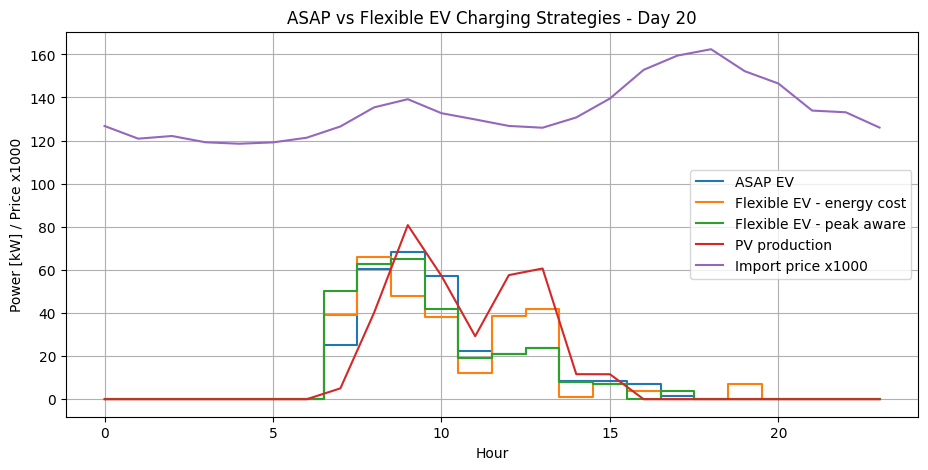

In [28]:
# ==========================================================
# Plot EV charging profiles
# ==========================================================

hours = np.arange(24)

plt.figure(figsize=(11,5))

plt.step(hours, ev_asap, where="mid", label="ASAP EV")
plt.step(hours, flex_energy["ev_profile"], where="mid", label="Flexible EV - energy cost")
plt.step(hours, flex_peak["ev_profile"], where="mid", label="Flexible EV - peak aware")
plt.plot(hours, flex_energy["pv_day"], label="PV production")
plt.plot(hours, (1.1 * flex_energy["price_day"] + 0.05) * 1000, label="Import price x1000")

plt.xlabel("Hour")
plt.ylabel("Power [kW] / Price x1000")
plt.title("ASAP vs Flexible EV Charging Strategies - Day 20")
plt.grid()
plt.legend()

plt.show()

A peak-aware objective was tested and it reduced peak grid import, but the main project focus remains cost-oriented day-ahead EV charging following the OSOPSS scheduling formulation.

In [29]:
# ==========================================================
# Function: evaluate a schedule using the same cost model
#
# This lets us fairly compare:
# - ASAP
# - Energy-flexible
# - Peak-aware flexible
#
# using the same original peak penalty.
# ==========================================================

def evaluate_schedule_cost(
    grid_import,
    grid_export,
    peak_grid,
    price_day,
    peak_penalty=4.0 / 30.0
):

    p_E_plus = 1.1 * price_day + 0.05
    p_E_minus = 0.9 * price_day - 0.01

    energy_cost = np.sum(
        p_E_plus * grid_import
        - p_E_minus * grid_export
    )

    peak_cost = peak_penalty * peak_grid

    total_cost = energy_cost + peak_cost

    return {
        "energy_cost_EUR": energy_cost,
        "peak_cost_EUR": peak_cost,
        "total_cost_EUR": total_cost
    }

In [30]:
# ==========================================================
# Fair cost comparison using same original cost function
# ==========================================================

asap_eval = evaluate_schedule_cost(
    asap_osopss["grid_import"],
    asap_osopss["grid_export"],
    asap_osopss["peak_grid_import"],
    asap_osopss["price_day"],
    peak_penalty=4.0 / 30.0
)

energy_flex_eval = evaluate_schedule_cost(
    flex_energy["grid_import"],
    flex_energy["grid_export"],
    flex_energy["peak_grid_import"],
    flex_energy["price_day"],
    peak_penalty=4.0 / 30.0
)

peak_flex_eval = evaluate_schedule_cost(
    flex_peak["grid_import"],
    flex_peak["grid_export"],
    flex_peak["peak_grid_import"],
    flex_peak["price_day"],
    peak_penalty=4.0 / 30.0
)

fair_comparison = pd.DataFrame([
    {
        "Strategy": "ASAP",
        "Fair_cost_EUR": asap_eval["total_cost_EUR"],
        "Energy_cost_EUR": asap_eval["energy_cost_EUR"],
        "Peak_cost_EUR": asap_eval["peak_cost_EUR"],
        "Grid_import_kWh": asap_osopss["grid_import"].sum(),
        "Grid_export_kWh": asap_osopss["grid_export"].sum(),
        "Peak_grid_kW": asap_osopss["peak_grid_import"],
        "Peak_EV_kW": ev_asap.max()
    },
    {
        "Strategy": "Flexible energy-cost",
        "Fair_cost_EUR": energy_flex_eval["total_cost_EUR"],
        "Energy_cost_EUR": energy_flex_eval["energy_cost_EUR"],
        "Peak_cost_EUR": energy_flex_eval["peak_cost_EUR"],
        "Grid_import_kWh": flex_energy["grid_import"].sum(),
        "Grid_export_kWh": flex_energy["grid_export"].sum(),
        "Peak_grid_kW": flex_energy["peak_grid_import"],
        "Peak_EV_kW": flex_energy["ev_profile"].max()
    },
    {
        "Strategy": "Flexible peak-aware",
        "Fair_cost_EUR": peak_flex_eval["total_cost_EUR"],
        "Energy_cost_EUR": peak_flex_eval["energy_cost_EUR"],
        "Peak_cost_EUR": peak_flex_eval["peak_cost_EUR"],
        "Grid_import_kWh": flex_peak["grid_import"].sum(),
        "Grid_export_kWh": flex_peak["grid_export"].sum(),
        "Peak_grid_kW": flex_peak["peak_grid_import"],
        "Peak_EV_kW": flex_peak["ev_profile"].max()
    }
])

fair_comparison.round(2)

,Strategy,Fair_cost_EUR,Energy_cost_EUR,Peak_cost_EUR,Grid_import_kWh,Grid_export_kWh,Peak_grid_kW,Peak_EV_kW
0,ASAP,200.09,190.25,9.83,1438.63,0.0,73.76,68.50
1,Flexible energy-cost,198.79,188.17,10.63,1435.17,0.0,79.70,66.19
2,Flexible peak-aware,201.01,192.78,8.23,1443.34,0.0,61.73,65.10


In [32]:
fair_comparison.to_csv(
    "../results/tables/notebook15_flexible_EV_day20_comparison.csv",
    index=False
)

print("Notebook 15 comparison saved.")

Notebook 15 comparison saved.


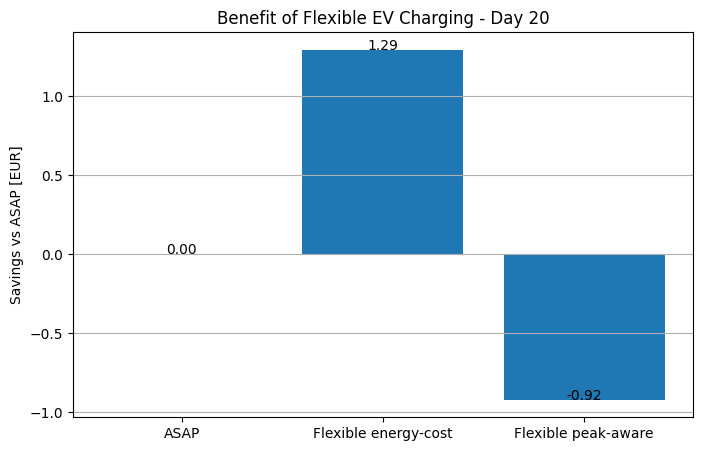

In [35]:
# ==========================================================
# Cost savings relative to ASAP
# ==========================================================

baseline = fair_comparison.loc[
    fair_comparison["Strategy"] == "ASAP",
    "Fair_cost_EUR"
].values[0]

savings = baseline - fair_comparison["Fair_cost_EUR"]

plt.figure(figsize=(8,5))

plt.bar(
    fair_comparison["Strategy"],
    savings
)

for i, value in enumerate(savings):
    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center"
    )

plt.ylabel("Savings vs ASAP [EUR]")
plt.title("Benefit of Flexible EV Charging - Day 20")
plt.grid(axis="y")

plt.show()

In [37]:
# ==========================================================
# Representative EV demand scenarios
# ==========================================================

scenario_days = {
    "Low": 106,
    "Medium": 20,
    "High": 95
}

scenario_days

{'Low': 106, 'Medium': 20, 'High': 95}

In [38]:
# ==========================================================
# Run OSOPSS flexible EV scheduling for all scenarios
#
# Comparison:
# 1) ASAP EV charging as fixed load
# 2) Flexible EV charging optimized inside parking windows
#
# Both use the same OSOPSS cost model.
# ==========================================================

scenario_flexible_results = []

for scenario_name, day_number in scenario_days.items():

    print(f"Running scenario: {scenario_name} - Day {day_number}")

    # ------------------------------------------------------
    # Build ASAP profile
    # ------------------------------------------------------

    ev_day = ev[
        ev["day"] == day_number
    ].copy()

    ev_asap = build_asap_profile(
        ev_day,
        P_EV_max=7.0
    )

    # ------------------------------------------------------
    # ASAP fixed-load case
    # ------------------------------------------------------

    asap_result = solve_osopss_daily_fixed_load(
        day_number,
        extra_load=ev_asap,
        peak_penalty=4.0 / 30.0
    )

    # ------------------------------------------------------
    # Flexible EV case
    # ------------------------------------------------------

    flex_result = solve_flexible_ev_day_ahead(
        day_number,
        peak_penalty=4.0 / 30.0
    )

    # ------------------------------------------------------
    # Store results
    # ------------------------------------------------------

    scenario_flexible_results.append({

        "Scenario": scenario_name,
        "Day": day_number,

        "EV_energy_kWh":
            ev_asap.sum(),

        "ASAP_cost_EUR":
            asap_result["cost_EUR"],

        "Flexible_cost_EUR":
            flex_result["cost_EUR"],

        "Cost_saving_EUR":
            asap_result["cost_EUR"]
            - flex_result["cost_EUR"],

        "ASAP_grid_import_kWh":
            asap_result["grid_import"].sum(),

        "Flexible_grid_import_kWh":
            flex_result["grid_import"].sum(),

        "Grid_import_reduction_kWh":
            asap_result["grid_import"].sum()
            - flex_result["grid_import"].sum(),

        "ASAP_grid_export_kWh":
            asap_result["grid_export"].sum(),

        "Flexible_grid_export_kWh":
            flex_result["grid_export"].sum(),

        "Grid_export_change_kWh":
            flex_result["grid_export"].sum()
            - asap_result["grid_export"].sum(),

        "ASAP_peak_grid_kW":
            asap_result["peak_grid_import"],

        "Flexible_peak_grid_kW":
            flex_result["peak_grid_import"],

        "Peak_grid_reduction_kW":
            asap_result["peak_grid_import"]
            - flex_result["peak_grid_import"],

        "ASAP_peak_EV_kW":
            ev_asap.max(),

        "Flexible_peak_EV_kW":
            flex_result["ev_profile"].max()
    })

scenario_flexible_df = pd.DataFrame(
    scenario_flexible_results
)

scenario_flexible_df.round(2)

Running scenario: Low - Day 106
Running scenario: Medium - Day 20
Running scenario: High - Day 95


,Scenario,Day,EV_energy_kWh,ASAP_cost_EUR,Flexible_cost_EUR,Cost_saving_EUR,ASAP_grid_import_kWh,Flexible_grid_import_kWh,Grid_import_reduction_kWh,ASAP_grid_export_kWh,Flexible_grid_export_kWh,Grid_export_change_kWh,ASAP_peak_grid_kW,Flexible_peak_grid_kW,Peak_grid_reduction_kW,ASAP_peak_EV_kW,Flexible_peak_EV_kW
0,Low,106,37.0,-67.84,-70.11,2.27,155.54,155.54,0.00,1725.48,1725.48,0.0,15.61,15.61,0.00,11.8,27.00
1,Medium,20,303.0,200.09,198.79,1.29,1438.63,1435.17,3.46,0.00,0.00,0.0,73.76,79.70,-5.94,68.5,66.19
2,High,95,509.0,-37.22,-41.70,4.48,128.91,128.91,0.00,1399.11,1399.11,0.0,20.95,20.95,0.00,127.9,181.95


In [39]:
scenario_flexible_df.to_csv(
    "../results/tables/notebook15_OSOPSS_flexible_EV_scenario_comparison.csv",
    index=False
)

print("Notebook 15 scenario comparison saved.")

Notebook 15 scenario comparison saved.


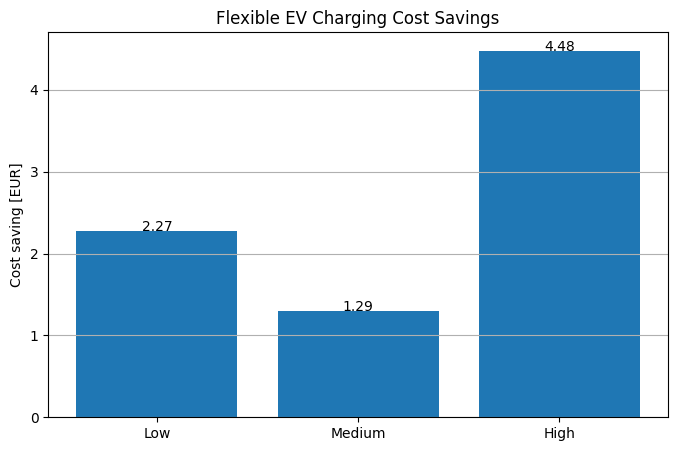

In [40]:
plt.figure(figsize=(8,5))

plt.bar(
    scenario_flexible_df["Scenario"],
    scenario_flexible_df["Cost_saving_EUR"]
)

plt.ylabel("Cost saving [EUR]")
plt.title("Flexible EV Charging Cost Savings")

for i, v in enumerate(scenario_flexible_df["Cost_saving_EUR"]):
    plt.text(i, v, f"{v:.2f}", ha="center")

plt.grid(axis="y")
plt.show()

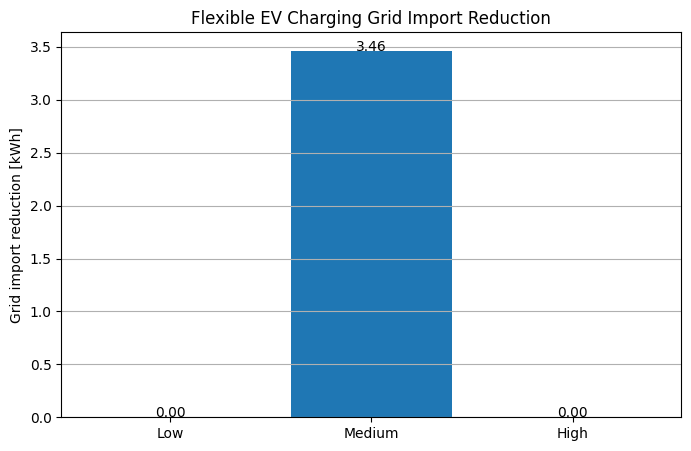

In [41]:
plt.figure(figsize=(8,5))

plt.bar(
    scenario_flexible_df["Scenario"],
    scenario_flexible_df["Grid_import_reduction_kWh"]
)

plt.ylabel("Grid import reduction [kWh]")
plt.title("Flexible EV Charging Grid Import Reduction")

for i, v in enumerate(
    scenario_flexible_df["Grid_import_reduction_kWh"]
):
    plt.text(i, v, f"{v:.2f}", ha="center")

plt.grid(axis="y")
plt.show()

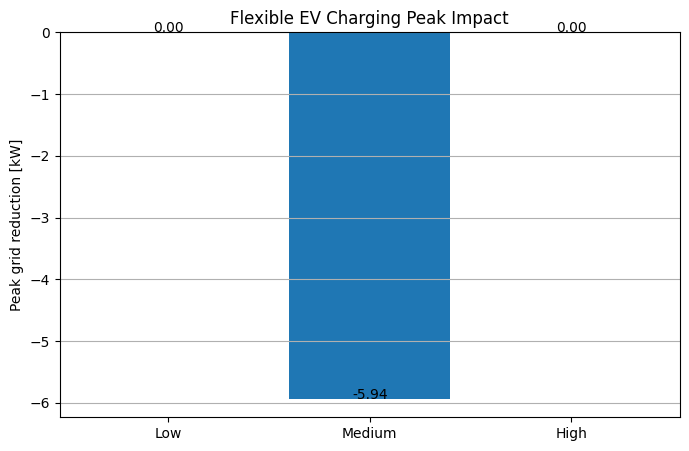

In [42]:
plt.figure(figsize=(8,5))

plt.bar(
    scenario_flexible_df["Scenario"],
    scenario_flexible_df["Peak_grid_reduction_kW"]
)

plt.ylabel("Peak grid reduction [kW]")
plt.title("Flexible EV Charging Peak Impact")

for i, v in enumerate(
    scenario_flexible_df["Peak_grid_reduction_kW"]
):
    plt.text(i, v, f"{v:.2f}", ha="center")

plt.grid(axis="y")
plt.show()